In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/insurance_data.csv')
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


# To understand the dataset

1. Age:

* Age of the customer
* Numerical

2. Sex:

* Gender of the customer(male/female)
* Categorical

3. bmi

* Body mass index
* Nmerical
* higher bmi -> higher health risk -> higher charges

4. Children

* number of dependents
* numerical
* More dependents -> Higher insurance cost

5. Smoker

* Whether the person smokes(yes/no)
* Categorical
* very important feature
* smoker usually have higher charges

6. Claim_amount:

* Amount claimed by the customer earlier
* Numerical
* indicates past insurance usage

7. Past_consultations

* Number of doctor consulatations in the past
* numerical
* more consultations -> higher medical risk

8. num_of_steps

* Number of daily of steps
* numerical
* more steps -> healthier lifestyle

9. Hospital_expenditure:

* Total money spent in hospitals.
* numerical

10. number_of_past_hospitalized

* number of times hospitalized
* numerical
* shows severity of past health issues

11. Annual_salary

* Yearly income of the customer
* Numerical
* Higher salary -> Higher insurance plans

12. Region

* Residential area(north,south,etc)
* Categorical

13. Charges: Target

* Insurance amount charged to the customer.
* Numerical
* This is what we predict using linear regression.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
# EDA -> Exploratory data analysis
# null values
# duplicates
# outliers
# label encoder


In [ ]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].mean())

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

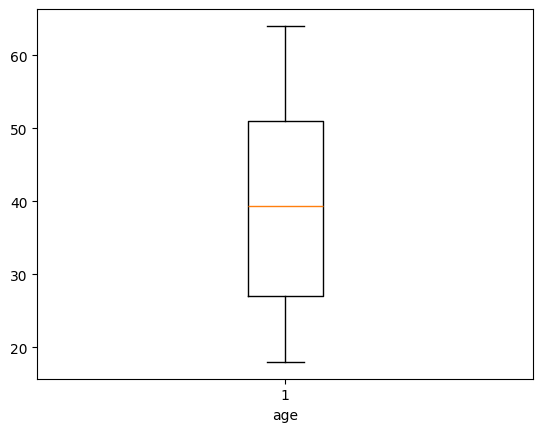

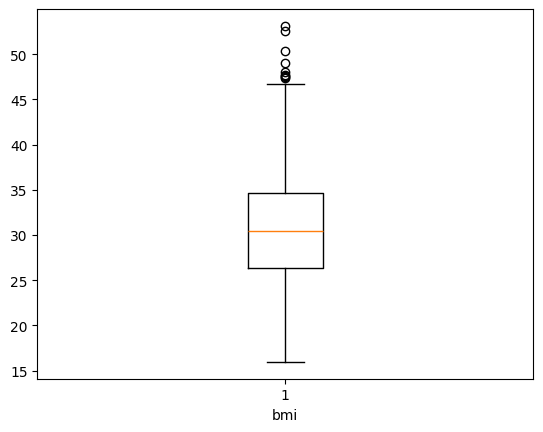

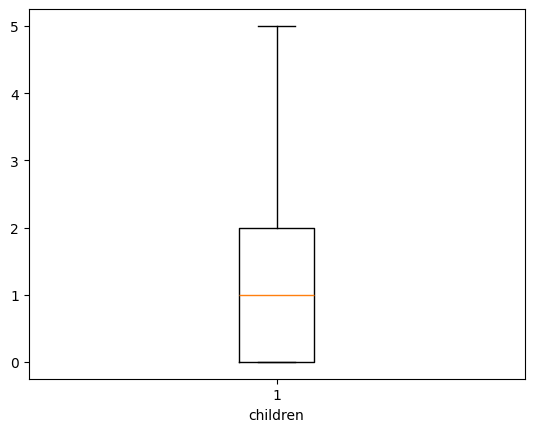

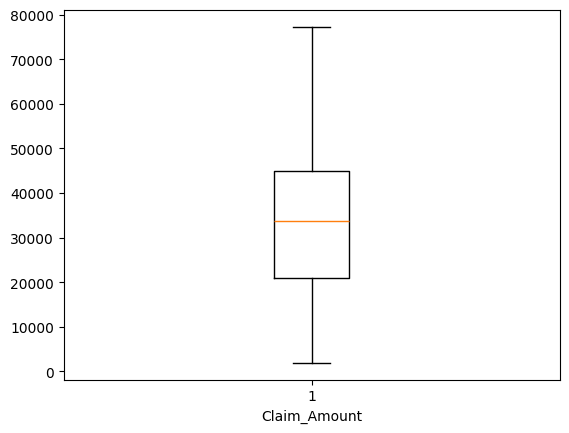

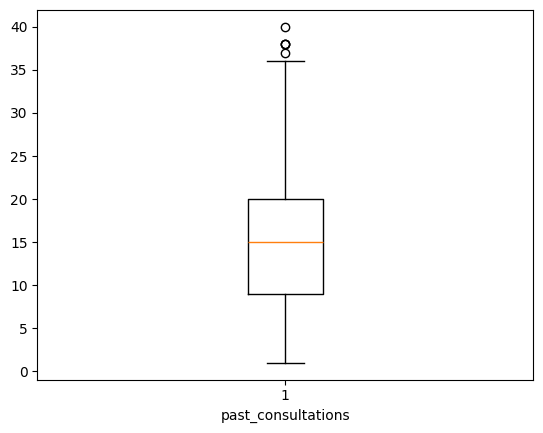

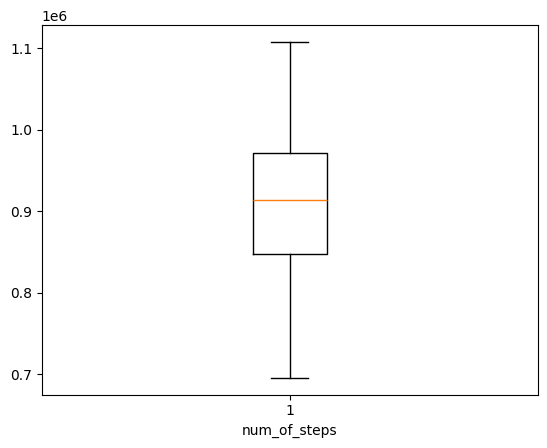

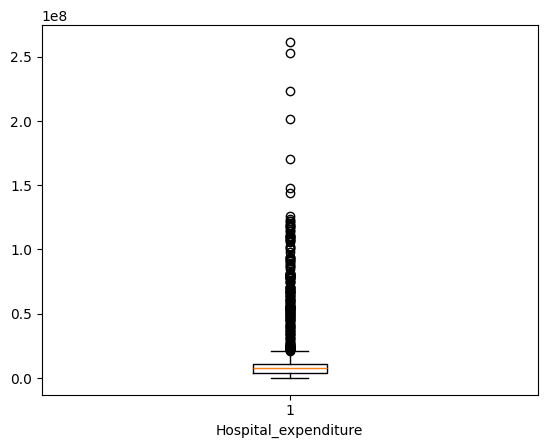

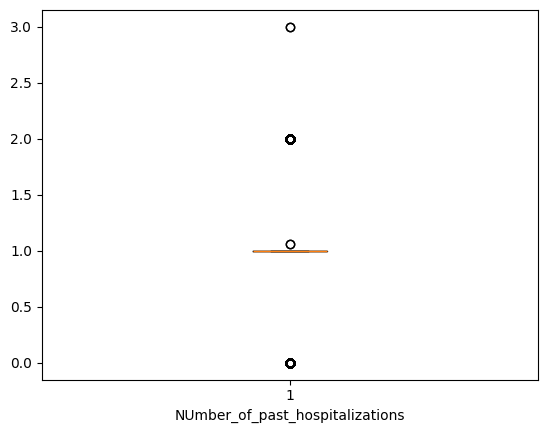

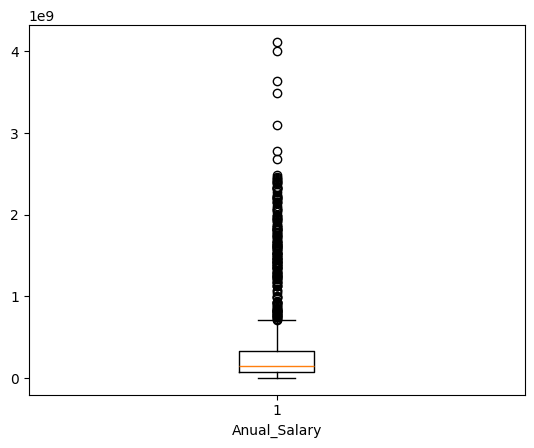

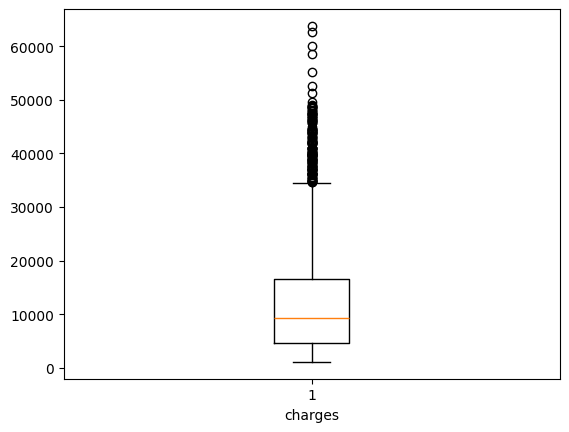

In [ ]:
for col in df.columns:
  if (df[col].dtype!='object'):
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
out_list = ['bmi','past_consultations','Hospital_expenditure','Anual_Salary']

for col in out_list:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3-Q1

  LB = Q1-1.5*(IQR)    # Values below this are considered as outliers
  UB = Q3+1.5*(IQR)    # values above this are considered as outliers

  df = df[(df[col]>=LB) & (df[col]<=UB)]  # this means that it will keep the values within range



In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,24.0,female,27.600,0.0,no,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,southwest,18955.22017
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [ ]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=LE.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1019 non-null   float64
 1   sex                              1019 non-null   int64  
 2   bmi                              1019 non-null   float64
 3   children                         1019 non-null   float64
 4   smoker                           1019 non-null   int64  
 5   Claim_Amount                     1019 non-null   float64
 6   past_consultations               1019 non-null   float64
 7   num_of_steps                     1019 non-null   float64
 8   Hospital_expenditure             1019 non-null   float64
 9   NUmber_of_past_hospitalizations  1019 non-null   float64
 10  Anual_Salary                     1019 non-null   float64
 11  region                           1019 non-null   int64  
 12  charges                  

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,24.0,0,27.600,0.0,0,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,3,18955.22017
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2,19350.36890
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0,19798.05455


In [ ]:
# model building
# 1. Splitting the data x,y
# 2. Splitting in terms of testing and training
# 3. model initialization
# 4. Train model
# 5. predistions

In [ ]:
x = df.iloc[:,:-1]
y = df['charges']

In [ ]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1041,24.0,0,27.600,0.0,0,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,3
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [ ]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1041,18955.22017
1046,19107.77960
1050,19350.36890
1062,19798.05455


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.80,random_state=0)

In [ ]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
745,56.0,1,34.430,0.000000,0,50004.294480,19.0,918901.0,2012873.659,1.0,1.271488e+08,2
207,25.0,0,20.800,1.000000,0,46151.179040,19.0,806649.0,6917444.679,1.0,4.440663e+07,3
243,30.0,1,31.400,1.000000,0,26117.194150,9.0,811131.0,5333413.619,1.0,3.812884e+07,3
5,18.0,1,34.430,0.000000,0,26488.339120,20.0,717162.0,3696160.701,0.0,3.696849e+08,2
360,34.0,0,27.500,1.090773,0,25534.067310,10.0,835922.0,7847499.198,1.0,1.090639e+08,3
...,...,...,...,...,...,...,...,...,...,...,...,...
846,57.0,0,22.230,0.000000,0,27388.677040,18.0,950172.0,7295767.757,1.0,1.789610e+08,0
195,28.0,1,30.875,0.000000,0,38337.554390,7.0,790896.0,2009909.133,1.0,4.823351e+07,1
635,46.0,0,30.200,2.000000,0,34890.647360,22.0,896509.0,2007539.609,1.0,8.608752e+07,3
564,48.0,1,29.700,0.000000,0,16861.596450,19.0,898133.0,5513110.693,1.0,1.509226e+08,2


In [ ]:
y_train

,charges
745,10594.22570
207,3208.78700
243,3659.34600
5,1137.46970
360,5003.85300
...,...
846,12029.28670
195,3062.50825
635,8825.08600
564,7789.63500


In [ ]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
484,36.0,1,27.550,3.0,0,49292.199920,7.0,868270.0,3.732688e+05,1.0,8.403831e+07,0
438,34.0,0,29.260,3.0,0,28578.499090,18.0,886628.0,8.616323e+06,1.0,6.663892e+07,2
250,31.0,0,29.100,0.0,0,29652.920720,21.0,825150.0,7.753482e+06,1.0,3.092081e+07,3
793,33.0,1,42.460,1.0,0,36343.864730,11.0,933484.0,8.089966e+06,1.0,2.023595e+08,2
28,18.0,0,31.350,0.0,0,33972.562340,3.0,743440.0,8.005326e+06,0.0,4.979936e+06,2
...,...,...,...,...,...,...,...,...,...,...,...,...
757,55.0,1,28.975,0.0,0,38053.139550,7.0,932554.0,2.488116e+06,1.0,1.984807e+08,0
320,32.0,0,29.590,1.0,0,4414.416523,9.0,835450.0,1.444796e+06,1.0,2.527777e+07,2
1032,23.0,0,28.490,1.0,1,19140.201170,23.0,978374.0,1.290713e+07,1.0,3.529098e+08,2
633,46.0,0,28.900,2.0,0,35381.297220,14.0,921295.0,3.515605e+06,1.0,1.008691e+08,3


In [ ]:
y_test

,charges
484,6746.74250
438,6184.29940
250,3761.29200
793,11326.71487
28,1622.18850
...,...
757,10796.35025
320,4562.84210
1032,18328.23810
633,8823.27900


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([ 6156.54854836,  6918.25123606,  3563.21967312, 10911.29750231,
         672.29777397, -1285.02441034,  4479.97737603, 11038.63578619,
        3925.89261247, 12959.14802361,  5246.67812716, 14343.58442431,
        3716.40610825, 12660.50830154, 12276.46302534,  9943.12851851,
        7175.74792953,  9769.52791094,  4631.87756891,  2674.39576751,
        9344.16112041,  6807.44847189,  8602.8228947 ,  7202.62783878,
        3680.80632775,  3428.73138796,   435.91858553,  8116.99531414,
        4975.60497372,  7187.70384802, 10058.2508066 , 11762.14775105,
       12177.60189261,  8308.49638276,  6532.52458608,  6233.31379787,
        1833.52801292,  4098.51963875, 11020.10648888, 13787.53186882,
       10110.78593119,  6658.29411532,  1456.01322534,  1622.64949537,
       12790.81360935,  6724.16615971,  6370.92363163,  2853.98837344,
        5182.18243393,  7514.05317297, 11864.17624226, 11094.75636482,
        9566.70083684,  4568.34882085,  1160.7585018 , 16653.75798028,
      

In [ ]:
y_test

,charges
484,6746.74250
438,6184.29940
250,3761.29200
793,11326.71487
28,1622.18850
...,...
757,10796.35025
320,4562.84210
1032,18328.23810
633,8823.27900


In [ ]:
results = pd.DataFrame(columns=['Actual_values','Predicted_values'])
results['Actual_values'] = y_test
results['predicted_values'] = y_pred
results

,Actual_values,Predicted_values,predicted_values
484,6746.74250,NaN,6156.548548
438,6184.29940,NaN,6918.251236
250,3761.29200,NaN,3563.219673
793,11326.71487,NaN,10911.297502
28,1622.18850,NaN,672.297774
...,...,...,...
757,10796.35025,NaN,11423.064800
320,4562.84210,NaN,3823.445009
1032,18328.23810,NaN,17502.719676
633,8823.27900,NaN,9233.754479


In [ ]:
from sklearn.metrics import *


In [ ]:
result = r2_score(y_test,y_pred)
result*100

95.0167673909687